# Notebook 8: eight-class PBMC3k → PBMC4k controlled test

This experiment asks whether removing the two donor-specific rare classes improves the original transfer direction.

- Remove 11 platelet cells from PBMC3k model development.
- Remove 34 dendritic cells from the PBMC4k external evaluation.
- Reproduce the original PBMC3k split before filtering.
- Use the original selected XGBoost settings without retuning on PBMC4k.
- Compare the new eight-class model with the frozen nine-class model on the exact same 4,097 PBMC4k cells.

The donor-specific annotated objects and frozen original model remain unchanged. Reviewed marker labels are proxy references, not definitive biological ground truth.

## 1. Imports, paths, and fixed settings

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.20
TEST_SIZE = 0.10
N_SELECTED_GENES = 2000
LOW_CONFIDENCE_THRESHOLD = 0.50
FIGURE_DPI = 180

cwd = Path.cwd().resolve()
root_candidates = []
for location in [cwd, *cwd.parents]:
    root_candidates.extend([location, location / "26-the-backpropagators-analysis"])
ROOT = next((p for p in root_candidates if (p / "PBMC3k").is_dir() and (p / "PBMC4k").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError(f"Could not locate the analysis repository from {cwd}")

P3_INPUT = ROOT / "PBMC3k" / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad"
P4_INPUT = ROOT / "PBMC4k" / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad"
FROZEN_MODEL_PATH = ROOT / "PBMC3k" / "models" / "pbmc_cell_classifier.joblib"
FROZEN_METADATA_PATH = ROOT / "PBMC3k" / "models" / "pbmc_cell_classifier_metadata.json"
INTEGRATED = ROOT / "PBMC_integrated"
MODELS = INTEGRATED / "models"
TABLES = INTEGRATED / "results" / "tables"
FIGURES = INTEGRATED / "results" / "figures"
DATA_OUT = INTEGRATED / "data" / "processed"
for directory in (MODELS, TABLES, FIGURES, DATA_OUT):
    directory.mkdir(parents=True, exist_ok=True)

MODEL_OUT = MODELS / "pbmc3k_shared8_controlled_xgboost.joblib"
METADATA_OUT = MODELS / "pbmc3k_shared8_controlled_xgboost_metadata.json"
PREDICTION_OUT = DATA_OUT / "pbmc4k_shared8_xgboost_external_validation.h5ad"
frozen_hash_before = hashlib.sha256(FROZEN_MODEL_PATH.read_bytes()).hexdigest()
print(f"Repository root: {ROOT}")

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis


## 2. Reproduce the original PBMC3k split, then exclude platelets

The nine-class split is reproduced first so every non-platelet cell stays in the same original partition. This controls the comparison: the new model receives the original training cells except for platelets.

In [2]:
pbmc3k = sc.read_h5ad(P3_INPUT)
pbmc4k = sc.read_h5ad(P4_INPUT)
frozen_model = joblib.load(FROZEN_MODEL_PATH)
frozen_metadata = json.loads(FROZEN_METADATA_PATH.read_text())

X3 = sparse.csr_matrix(pbmc3k.raw.X.astype(np.float64))
labels3 = pbmc3k.obs["cell_type"].astype(str).to_numpy()
original_encoder = LabelEncoder()
y_original = original_encoder.fit_transform(labels3)
indices = np.arange(pbmc3k.n_obs)
development_idx, original_test_idx = train_test_split(
    indices, test_size=TEST_SIZE, stratify=y_original, random_state=RANDOM_STATE
)
validation_fraction = VALIDATION_SIZE / (TRAIN_SIZE + VALIDATION_SIZE)
original_train_idx, original_validation_idx = train_test_split(
    development_idx,
    test_size=validation_fraction,
    stratify=y_original[development_idx],
    random_state=RANDOM_STATE,
)
assert (len(original_train_idx), len(original_validation_idx), len(original_test_idx)) == (1846, 528, 264)

platelet_label = "Platelets"
shared8_classes = np.asarray([label for label in original_encoder.classes_ if label != platelet_label])
shared8_encoder = LabelEncoder().fit(shared8_classes)
train_idx = original_train_idx[labels3[original_train_idx] != platelet_label]
validation_idx = original_validation_idx[labels3[original_validation_idx] != platelet_label]
test_idx = original_test_idx[labels3[original_test_idx] != platelet_label]
y_train = shared8_encoder.transform(labels3[train_idx])
y_validation = shared8_encoder.transform(labels3[validation_idx])
y_test = shared8_encoder.transform(labels3[test_idx])

split_summary = pd.DataFrame({
    "original_nine_class_cells": [len(original_train_idx), len(original_validation_idx), len(original_test_idx)],
    "shared8_cells": [len(train_idx), len(validation_idx), len(test_idx)],
    "platelets_removed": [
        np.sum(labels3[original_train_idx] == platelet_label),
        np.sum(labels3[original_validation_idx] == platelet_label),
        np.sum(labels3[original_test_idx] == platelet_label),
    ],
}, index=["train", "validation", "test"])
display(split_summary)
print("Eight supported classes:", shared8_encoder.classes_.tolist())

,original_nine_class_cells,shared8_cells,platelets_removed
train,1846,1838,8
validation,528,526,2
test,264,263,1


Eight supported classes: ['Activated/transitional T cells', 'B cells', 'CD16+ non-classical monocytes', 'Classical monocytes', 'Cytotoxic CD8 T cells', 'IL7R+ memory/helper T cells', 'NK cells', 'Naive/resting T cells']


## 3. Fit the controlled eight-class model

The frozen model's selected settings—depth 6 and learning rate 0.1—are reused. There is no PBMC4k tuning.

In [3]:
frozen_classifier = frozen_model.named_steps["classifier"]
assert frozen_classifier.get_params()["max_depth"] == 6
assert np.isclose(frozen_classifier.get_params()["learning_rate"], 0.1)

shared8_model = Pipeline([
    ("variance", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=N_SELECTED_GENES)),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=250,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
shared8_model.fit(X3[train_idx], y_train)

def internal_metrics(indices_to_score, encoded_truth):
    pred = shared8_model.predict(X3[indices_to_score])
    return {
        "accuracy": accuracy_score(encoded_truth, pred),
        "balanced_accuracy": balanced_accuracy_score(encoded_truth, pred),
        "macro_f1": f1_score(encoded_truth, pred, average="macro"),
    }

internal_scores = pd.DataFrame({
    "validation": internal_metrics(validation_idx, y_validation),
    "test": internal_metrics(test_idx, y_test),
}).T
internal_scores.to_csv(TABLES / "pbmc_shared8_controlled_internal_scores.csv")
display(internal_scores.round(4))

,accuracy,balanced_accuracy,macro_f1
validation,0.9297,0.8999,0.9156
test,0.9163,0.8935,0.9014


## 4. Align PBMC4k to the PBMC3k feature schema and remove dendritic cells

In [4]:
dendritic_label = "Dendritic cells"
pbmc4k_shared8 = pbmc4k[pbmc4k.obs["cell_type"].astype(str) != dendritic_label].copy()
true_external = pbmc4k_shared8.obs["cell_type"].astype(str).to_numpy()
assert set(np.unique(true_external)) == set(shared8_encoder.classes_)
assert pbmc4k_shared8.n_obs == 4097

model_genes = pd.Index(pbmc3k.raw.var_names.astype(str))
source_genes = pd.Index(pbmc4k_shared8.raw.var_names.astype(str))
source_positions = source_genes.get_indexer(model_genes)
present_mask = source_positions >= 0
present_model_columns = np.flatnonzero(present_mask)
source_matrix = sparse.csr_matrix(pbmc4k_shared8.raw.X[:, source_positions[present_mask]])
coo = source_matrix.tocoo()
X_external = sparse.csr_matrix(
    (coo.data, (coo.row, present_model_columns[coo.col])),
    shape=(pbmc4k_shared8.n_obs, len(model_genes)),
)
print(f"PBMC4k shared-class cells: {pbmc4k_shared8.n_obs:,}")
print(f"PBMC3k-schema genes present: {present_mask.sum():,}/{len(model_genes):,}")
print(f"Dendritic cells excluded: {pbmc4k.n_obs - pbmc4k_shared8.n_obs}")

PBMC4k shared-class cells: 4,097
PBMC3k-schema genes present: 12,897/13,656
Dendritic cells excluded: 34


## 5. Compare the frozen nine-class and controlled eight-class models

In [5]:
frozen_classes = np.asarray(frozen_metadata["classes"])
frozen_encoded = frozen_model.predict(X_external).astype(int)
frozen_predictions = frozen_classes[frozen_encoded]
frozen_probabilities = frozen_model.predict_proba(X_external)

shared8_encoded = shared8_model.predict(X_external).astype(int)
shared8_predictions = shared8_encoder.classes_[shared8_encoded]
shared8_probabilities = shared8_model.predict_proba(X_external)

def external_score_row(name, predictions, probabilities):
    return {
        "model": name,
        "external_cells": len(true_external),
        "accuracy": accuracy_score(true_external, predictions),
        "balanced_accuracy": balanced_accuracy_score(true_external, predictions),
        "macro_f1": f1_score(true_external, predictions, labels=shared8_encoder.classes_, average="macro", zero_division=0),
        "weighted_f1": f1_score(true_external, predictions, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(true_external, predictions),
        "mean_max_probability": probabilities.max(axis=1).mean(),
        "low_confidence_percent": 100 * np.mean(probabilities.max(axis=1) < LOW_CONFIDENCE_THRESHOLD),
    }

comparison = pd.DataFrame([
    external_score_row("Frozen nine-class PBMC3k model", frozen_predictions, frozen_probabilities),
    external_score_row("Controlled eight-class PBMC3k model", shared8_predictions, shared8_probabilities),
]).set_index("model")
comparison["accuracy_change_vs_frozen"] = comparison["accuracy"] - comparison.iloc[0]["accuracy"]
comparison["macro_f1_change_vs_frozen"] = comparison["macro_f1"] - comparison.iloc[0]["macro_f1"]
comparison.to_csv(TABLES / "pbmc_shared8_pbmc4k_external_comparison.csv")
display(comparison.round(4))

report = pd.DataFrame(classification_report(
    true_external,
    shared8_predictions,
    labels=shared8_encoder.classes_,
    output_dict=True,
    zero_division=0,
)).T
report.to_csv(TABLES / "pbmc_shared8_pbmc4k_per_class_report.csv")
display(report.round(3))

/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,external_cells,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,mean_max_probability,low_confidence_percent,accuracy_change_vs_frozen,macro_f1_change_vs_frozen
model,,,,,,,,,,
Frozen nine-class PBMC3k model,4097,0.6925,0.8010,0.7158,0.6528,0.6990,0.9350,1.0251,0.0000,0.0000
Controlled eight-class PBMC3k model,4097,0.6898,0.7972,0.7137,0.6521,0.6962,0.9405,0.5614,-0.0027,-0.0021


,precision,recall,f1-score,support
Activated/transitional T cells,0.250,0.003,0.006,1075.00
B cells,0.990,0.998,0.994,592.00
CD16+ non-classical monocytes,0.980,0.934,0.957,106.00
Classical monocytes,0.995,0.990,0.992,923.00
Cytotoxic CD8 T cells,0.917,0.827,0.869,588.00
IL7R+ memory/helper T cells,0.666,0.957,0.785,440.00
NK cells,0.952,0.768,0.850,181.00
Naive/resting T cells,0.149,0.901,0.256,192.00
accuracy,0.690,0.690,0.690,0.69
macro avg,0.737,0.797,0.714,4097.00


## 6. Confusion matrix, predictions, and visual comparison

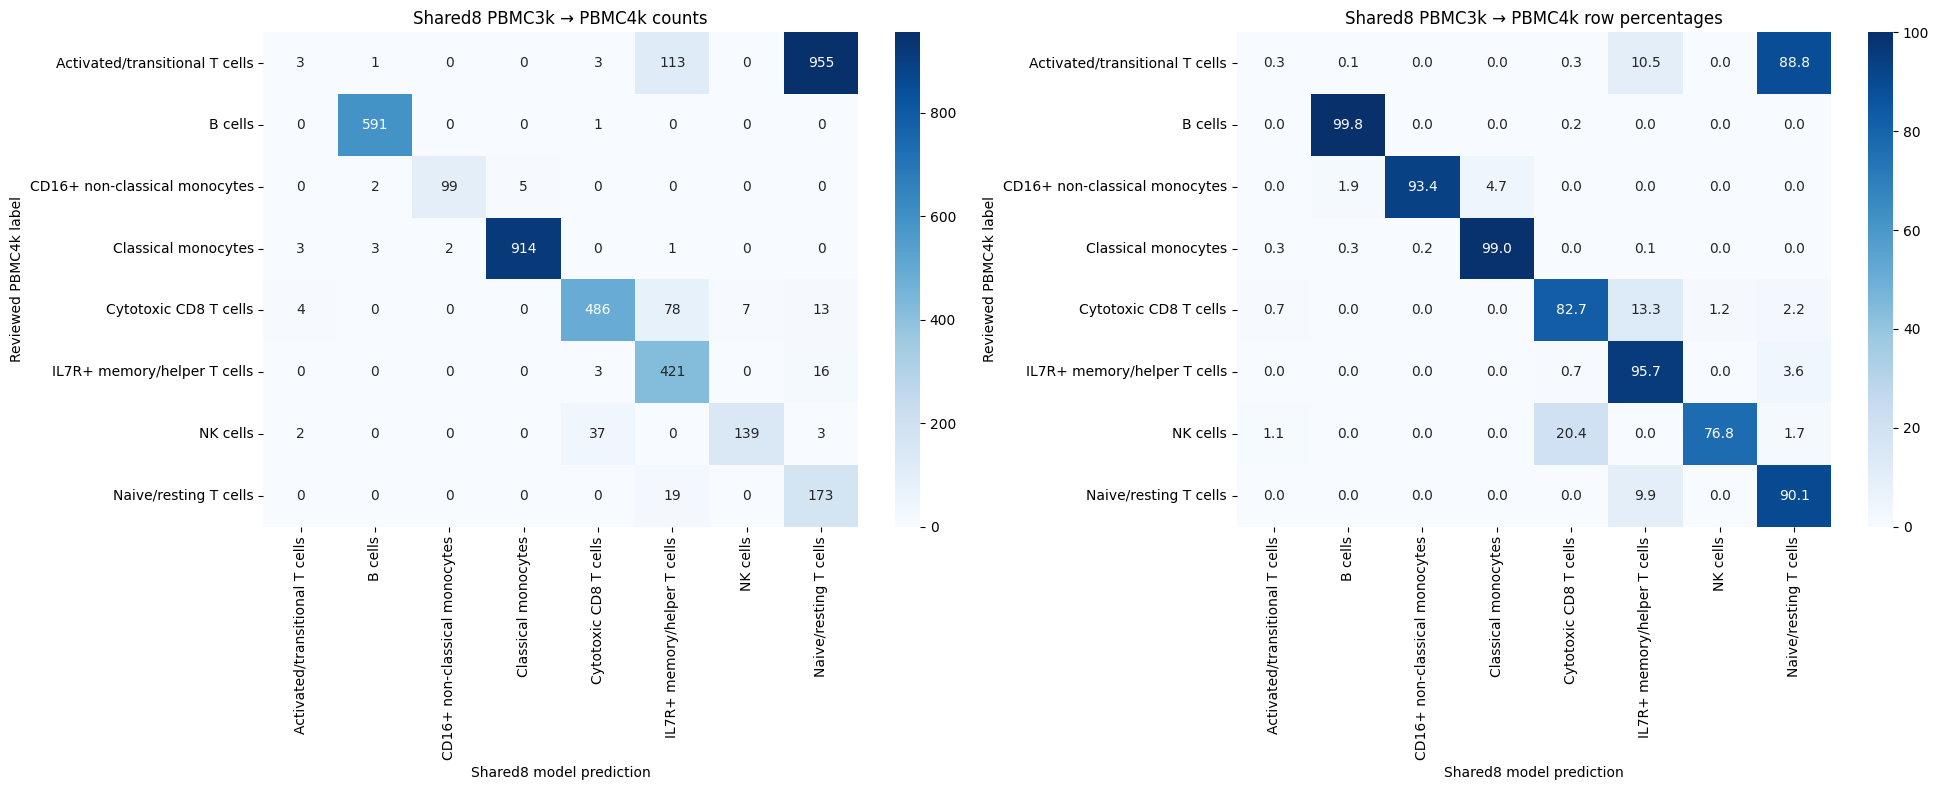

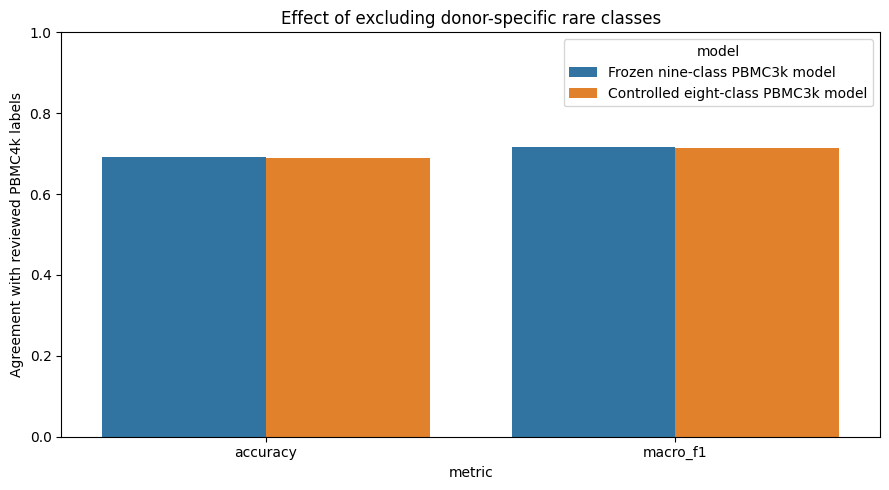

In [6]:
confusion_counts = pd.crosstab(
    pd.Categorical(true_external, categories=shared8_encoder.classes_, ordered=True),
    pd.Categorical(shared8_predictions, categories=shared8_encoder.classes_, ordered=True),
    rownames=["Reviewed PBMC4k label"],
    colnames=["Shared8 model prediction"],
    dropna=False,
)
confusion_percent = confusion_counts.div(confusion_counts.sum(axis=1), axis=0) * 100
confusion_counts.to_csv(TABLES / "pbmc_shared8_pbmc4k_confusion_counts.csv")
confusion_percent.to_csv(TABLES / "pbmc_shared8_pbmc4k_confusion_row_percent.csv")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(confusion_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Shared8 PBMC3k → PBMC4k counts")
sns.heatmap(confusion_percent, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, ax=axes[1])
axes[1].set_title("Shared8 PBMC3k → PBMC4k row percentages")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_shared8_pbmc4k_confusion_matrices.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

prediction_frame = pd.DataFrame({
    "cell_id": pbmc4k_shared8.obs_names.astype(str),
    "reviewed_cell_type": true_external,
    "frozen_nine_class_prediction": frozen_predictions,
    "shared8_prediction": shared8_predictions,
    "shared8_max_probability": shared8_probabilities.max(axis=1),
    "shared8_prediction_correct": shared8_predictions == true_external,
})
for i, label in enumerate(shared8_encoder.classes_):
    prediction_frame[f"probability__{label}"] = shared8_probabilities[:, i]
prediction_frame.to_csv(TABLES / "pbmc_shared8_pbmc4k_cell_predictions.csv", index=False)

plot_data = comparison.reset_index().melt(
    id_vars="model", value_vars=["accuracy", "macro_f1"], var_name="metric", value_name="score"
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.ylabel("Agreement with reviewed PBMC4k labels")
plt.title("Effect of excluding donor-specific rare classes")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc_shared8_pbmc4k_model_comparison.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## 7. Save separate artifacts and verify preservation

In [7]:
joblib.dump(shared8_model, MODEL_OUT)
model_hash = hashlib.sha256(MODEL_OUT.read_bytes()).hexdigest()
metadata = {
    "model": "Controlled eight-class PBMC3k XGBoost",
    "purpose": "Measure effect of excluding PBMC3k platelets and PBMC4k dendritic cells",
    "classes": shared8_encoder.classes_.tolist(),
    "gene_names": model_genes.tolist(),
    "training_cells": int(len(train_idx)),
    "validation_cells": int(len(validation_idx)),
    "internal_test_cells": int(len(test_idx)),
    "external_pbmc4k_cells": int(pbmc4k_shared8.n_obs),
    "excluded_pbmc3k_platelets": int(np.sum(labels3 == platelet_label)),
    "excluded_pbmc4k_dendritic_cells": int(pbmc4k.n_obs - pbmc4k_shared8.n_obs),
    "controlled_split": "Original nine-class PBMC3k split reproduced before filtering",
    "parameters": {"max_depth": 6, "learning_rate": 0.1, "n_estimators": 250},
    "external_accuracy": float(comparison.loc["Controlled eight-class PBMC3k model", "accuracy"]),
    "external_macro_f1": float(comparison.loc["Controlled eight-class PBMC3k model", "macro_f1"]),
    "harmony_coordinates_used": False,
    "model_sha256": model_hash,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
METADATA_OUT.write_text(json.dumps(metadata, indent=2) + "\n")

pbmc4k_shared8.obs["shared8_xgboost_prediction"] = pd.Categorical(shared8_predictions, categories=shared8_encoder.classes_)
pbmc4k_shared8.obs["shared8_xgboost_max_probability"] = shared8_probabilities.max(axis=1)
pbmc4k_shared8.obs["shared8_xgboost_prediction_correct"] = shared8_predictions == true_external
pbmc4k_shared8.uns["shared8_external_validation"] = {
    "training_dataset": "PBMC3k excluding platelets",
    "external_dataset": "PBMC4k excluding dendritic cells",
    "external_accuracy": metadata["external_accuracy"],
    "external_macro_f1": metadata["external_macro_f1"],
    "model_path": str(MODEL_OUT),
    "marker_labels_are_definitive_ground_truth": False,
}
pbmc4k_shared8.write_h5ad(PREDICTION_OUT, compression="gzip")

frozen_hash_after = hashlib.sha256(FROZEN_MODEL_PATH.read_bytes()).hexdigest()
if frozen_hash_after != frozen_hash_before:
    raise RuntimeError("The frozen original PBMC3k model changed.")
print(f"Saved controlled model: {MODEL_OUT}")
print(f"Saved filtered PBMC4k predictions: {PREDICTION_OUT}")
print(f"Frozen original model preserved: {frozen_hash_after}")

Saved controlled model: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/models/pbmc3k_shared8_controlled_xgboost.joblib
Saved filtered PBMC4k predictions: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/data/processed/pbmc4k_shared8_xgboost_external_validation.h5ad
Frozen original model preserved: cc8701edbb1b3726d788307acf8384e213594f414d47c3edf24eebc257ea1465


## Interpretation boundary

This is a controlled ablation experiment, not the final combined model. It shows whether removing the two unsupported rare classes changes PBMC3k-to-PBMC4k transfer. It does not solve inconsistent T-cell label definitions, and the eight-class model cannot recognize dendritic cells or platelets.